# 08 — Adaptive Routing

This is the second half of the project. Notebook 03 found that Abilene's OSPF
routing piles traffic onto one transcontinental corridor while parallel capacity
sits nearly idle — the busiest link reaches **75.4%** while `STTLng->SNVAng` never
exceeds **0.9%**. (That 75.4% peak is on `KSCYng,IPLSng`; `CHINng,IPLSng`, which
earlier notebooks used as the example, peaks at 70.2%. Both are reported below.)

That imbalance is the target. Here we reroute traffic with Dijkstra using edge
costs that rise with congestion, so busy links become expensive and flows spill
onto idle capacity.

**Three things to be clear about up front:**

1. This reroutes on **observed** congestion, not predicted congestion. Notebooks
   05–07 established that persistence — "what the link was doing at the last
   reading" — is the best available signal, and that no model we tried beat it.
   Using that signal directly is more honest than dressing it up as prediction.
2. The baseline is not asserted, it is **recomputed**. We run Dijkstra on the real
   historical OSPF weights and check it reproduces the utilisation from notebook 01
   before comparing anything against it.
3. Rerouting is not free. Moving a flow onto a longer path uses more total network
   capacity, and a scheme that relieves one link by overloading its neighbour has
   not achieved anything. Both are measured.

In [1]:
from pathlib import Path
import gzip

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

PROJECT = Path.cwd().parent
RAW = PROJECT / "data" / "raw" / "abilene"
PROCESSED = PROJECT / "data" / "processed"

pd.set_option("display.width", 200)
print("loading topology and demands...")

loading topology and demands...


In [2]:
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#c3c2b7"
INK, MUTED = "#0b0b0b", "#898781"

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "font.size": 9, "legend.frameon": False,
})
print("style set")

style set


## Step 1 — Topology, demands, and the graph

Same parsing as notebook 01: routers, directed links, real capacities and real
OSPF weights.

In [3]:
routers, link_rows, section = [], [], None
for line in (RAW / "topo-2003-04-10.txt").read_text().splitlines():
    line = line.strip()
    if line in ("router", "link"):
        section = line
        continue
    if not line or line.startswith("#"):
        continue
    parts = line.split()
    if section == "router":
        routers.append(parts[0])
    else:
        link_rows.append({"src": parts[0], "dst": parts[1],
                          "capacity_kbps": float(parts[2]), "ospf": float(parts[3])})

links = pd.DataFrame(link_rows)
links["link"] = links["src"] + "," + links["dst"]
link_position = {name: i for i, name in enumerate(links["link"])}
capacity = links["capacity_kbps"].to_numpy()

demands = pd.read_csv(RAW / "demands", sep=r"\s+", comment="#", names=["od", "idx"])
od_pairs = [tuple(o.split(",")) for o in demands["od"]]

# Directed graph carrying the real OSPF weights.
graph = nx.DiGraph()
for row in links.itertuples():
    graph.add_edge(row.src, row.dst, ospf=row.ospf, capacity=row.capacity_kbps)

print(f"{len(routers)} routers, {len(links)} directed links, {len(demands)} OD pairs")
print(f"OSPF weights: min {links.ospf.min():.0f}, max {links.ospf.max():.0f}")
print(f"capacities  : {sorted(set(links.capacity_kbps / 1e6))} Gbps")

12 routers, 30 directed links, 144 OD pairs
OSPF weights: min 1, max 2095
capacities  : [2.48, 9.92] Gbps


## Step 2 — Routing as a matrix

A routing is just "which links does each OD flow cross". We build that as a
`links x OD pairs` matrix of 0/1, exactly the same shape as the `A` file shipped
with the dataset. Then link loads are one matrix multiply:

```
link_loads = demand @ A.T
```

`route()` below takes a cost attribute, runs Dijkstra from every source, and
returns that matrix.

In [4]:
def route(cost_attribute):
    """Shortest-path routing matrix (links x OD pairs) under a given edge cost."""
    A = np.zeros((len(links), len(demands)))
    # One Dijkstra per source node gives paths to every destination.
    paths = dict(nx.all_pairs_dijkstra_path(graph, weight=cost_attribute))
    for column, (source, destination) in enumerate(od_pairs):
        if source == destination:
            continue                      # traffic that never enters the backbone
        hops = paths[source][destination]
        for a, b in zip(hops, hops[1:]):
            A[link_position[f"{a},{b}"], column] = 1.0
    return A


A_ospf = route("ospf")
print(f"routing matrix: {A_ospf.shape}, {int(A_ospf.sum())} (link, flow) placements")
print(f"mean path length: {A_ospf.sum(axis=0).mean():.2f} hops")

routing matrix: (30, 144), 356 (link, flow) placements
mean path length: 2.47 hops


### Verify the baseline before trusting it

The dataset ships its own routing matrix `A`, derived from the same OSPF weights.
If our Dijkstra is doing the right thing it should reproduce that file exactly —
not approximately.

In [5]:
shipped = pd.read_csv(RAW / "A", sep=r"\s+", comment="#",
                      names=["link", "od", "link_idx", "demand_idx", "frac"])
internal = set(links["link"])

A_shipped = np.zeros_like(A_ospf)
for row in shipped.itertuples():
    if row.link in internal:                       # ignore ingress/egress pseudo-links
        A_shipped[link_position[row.link], row.demand_idx - 1] = row.frac

print(f"unique fraction values in the shipped file: {sorted(shipped.frac.unique())}")
print("(all 1 means single-path routing - no ECMP splitting to reproduce)\n")
print(f"[{'PASS' if np.array_equal(A_shipped, A_ospf) else 'FAIL'}] "
      "Dijkstra on the real OSPF weights reproduces the shipped routing matrix "
      "exactly")

unique fraction values in the shipped file: [np.int64(1)]
(all 1 means single-path routing - no ECMP splitting to reproduce)

[PASS] Dijkstra on the real OSPF weights reproduces the shipped routing matrix exactly


## Step 3 — Load the OD demands

We need the actual traffic per OD pair, not just the resulting utilisation, because
rerouting changes where that traffic lands. Same loading rules as notebook 01: take
only the measured column of each group of five, convert from `100 bytes / 5 min` to
kbps, and drop the duplicated day where X20 and X21 overlap.

In [6]:
week_starts = {}
for line in (RAW / "readme.txt").read_text().splitlines():
    parts = line.split()
    if len(parts) == 2 and parts[1].startswith("X") and parts[1][1:].isdigit():
        week_starts[parts[1]] = pd.Timestamp(parts[0])

blocks = []
for name, start in sorted(week_starts.items()):
    with gzip.open(RAW / "traffic-matrices" / f"{name}.gz", "rt") as handle:
        raw = np.loadtxt(handle)
    measured = raw[:, 0::5]                                  # realOD only
    stamps = pd.date_range(start, periods=len(measured), freq="5min")
    blocks.append(pd.DataFrame(measured, index=stamps))

demand = pd.concat(blocks)
demand = demand[~demand.index.duplicated(keep="first")].sort_index()
demand_kbps = demand * (100 * 8 / 300 / 1000)

print(f"demand: {demand_kbps.shape[0]:,} timesteps x {demand_kbps.shape[1]} OD pairs")

demand: 48,096 timesteps x 144 OD pairs


In [7]:
# Loads and utilisation under the historical OSPF routing.
demand_matrix = demand_kbps.to_numpy()
loads_ospf = demand_matrix @ A_ospf.T
util_ospf = loads_ospf / capacity * 100

# Cross-check against the table notebook 01 produced.
reference = pd.read_parquet(PROCESSED / "abilene_link_utilization_wide.parquet")
reference.index = pd.DatetimeIndex(reference.index)
reference = reference[list(links["link"])]

matches = np.allclose(reference.to_numpy(), util_ospf, rtol=1e-9, atol=1e-9)
print(f"[{'PASS' if matches else 'FAIL'}] baseline utilisation matches notebook 01")
print(f"largest difference: "
      f"{np.abs(reference.to_numpy() - util_ospf).max():.3e} percentage points")
print(f"\nbaseline peak utilisation over the series: {util_ospf.max():.2f}%")

[PASS] baseline utilisation matches notebook 01
largest difference: 0.000e+00 percentage points

baseline peak utilisation over the series: 75.36%


## Step 4 — The cost function (a real design decision)

This is the choice that defines the whole component, so it is worth setting out
properly.

We want an edge cost that:

- **behaves like OSPF when the network is quiet.** Abilene averages 2.7%
  utilisation. If the adaptive scheme reshuffles paths when nothing is congested,
  it adds churn for no benefit.
- **rises sharply when a link gets busy**, so a congested link is avoided even if
  the detour is considerably longer in plain OSPF terms.
- **has no arbitrary tuning knobs** we would then have to justify.

The choice:

$$\text{cost}(e) = \frac{w(e)}{1 - u(e)}$$

where $w(e)$ is the link's real OSPF weight and $u(e)$ its utilisation as a
fraction.

**Why this form.** It is the standard M/M/1 queueing result: mean delay through a
link scales as $1/(1-\rho)$ in its load. So this is not an arbitrary penalty — it
approximates the actual delay a packet would experience, which is what a routing
metric is supposed to represent.

Its behaviour is exactly what we asked for:

| utilisation | cost multiplier |
|---|---|
| 3% (typical) | 1.03× — effectively OSPF |
| 25% | 1.33× |
| 50% | 2.0× |
| 75% (the corridor peak) | **4.0×** |

Utilisation is capped at 0.95 so the cost stays finite; nothing in this data comes
close.

**Does it actually bite?** The west-bound corridor costs 3108 in OSPF weight
(`CHIN->IPLS->KSCY->DNVR->SNVA->LOSA`). The best alternative from Chicago to Los
Angeles, via Houston, costs 3603 — 16% more. So a congested corridor only needs a
1.16× multiplier before the detour wins, which happens once utilisation passes
about 14%. At the 75% peak the corridor costs 4× and the detour is far cheaper.

**Which load do we use?** The most recently *observed* one — the previous
timestep's utilisation under the routing actually in force. This matters for
honesty: we cannot use time *t*'s load to route time *t*'s traffic, because the
routing is what determines that load. Using *t−5 min* is both physically coherent
and exactly the persistence signal notebooks 05–07 identified as the best
available. Where the previous timestep is missing (a data gap), we fall back to
plain OSPF costs.

In [8]:
UTIL_CAP = 0.95        # keeps the cost finite; nothing here gets close


def congestion_costs(utilisation_fraction):
    """M/M/1-style edge cost: OSPF weight inflated by 1 / (1 - utilisation)."""
    clipped = np.clip(utilisation_fraction, 0.0, UTIL_CAP)
    return links["ospf"].to_numpy() / (1.0 - clipped)


for u in (0.03, 0.25, 0.50, 0.75):
    print(f"  utilisation {u:>5.0%} -> cost multiplier {1 / (1 - u):.2f}x")

corridor = ["CHINng,IPLSng", "IPLSng,KSCYng", "KSCYng,DNVRng",
            "DNVRng,SNVAng", "SNVAng,LOSAng"]
detour = ["CHINng,IPLSng", "IPLSng,KSCYng", "KSCYng,HSTNng", "HSTNng,LOSAng"]
w = links.set_index("link")["ospf"]
print(f"\nChicago -> Los Angeles, OSPF weight:")
print(f"  corridor route : {w[corridor].sum():.0f}")
print(f"  via Houston    : {w[detour].sum():.0f}  "
      f"({w[detour].sum() / w[corridor].sum():.2f}x)")

  utilisation    3% -> cost multiplier 1.03x
  utilisation   25% -> cost multiplier 1.33x
  utilisation   50% -> cost multiplier 2.00x
  utilisation   75% -> cost multiplier 4.00x

Chicago -> Los Angeles, OSPF weight:
  corridor route : 3108
  via Houston    : 3603  (1.16x)


## Step 5 — First attempt: reroute everything at once (and why it fails)

The obvious implementation: at each timestep, take the last observed utilisation,
turn it into edge costs, run Dijkstra, and move every flow onto its new shortest
path.

This is worth running even though it does not work, because *how* it fails is the
whole design lesson.

In [9]:
import datetime

LOG = PROJECT / "logs" / "nb08_progress.log"
LOG.parent.mkdir(exist_ok=True)


def log(message):
    with open(LOG, "a") as handle:
        print(f"{datetime.datetime.now():%H:%M:%S}  {message}", file=handle)
    print(message)


def set_edge_costs(cost_vector):
    for row, name in enumerate(links["link"]):
        a, b = name.split(",")
        graph[a][b]["adaptive"] = cost_vector[row]


timestamps = demand_kbps.index
n_steps = len(timestamps)
demand_matrix = demand_kbps.to_numpy()
step = pd.Timedelta(minutes=5)

# Which timesteps have an observable previous reading (i.e. not after a gap)?
has_previous = np.zeros(n_steps, dtype=bool)
has_previous[1:] = (timestamps[1:] - timestamps[:-1]) == step

loads_simultaneous = np.zeros((n_steps, len(links)))
log("=== scheme 1: simultaneous rerouting ===")

for i in range(n_steps):
    if has_previous[i]:
        set_edge_costs(congestion_costs(util_ospf[i - 1] / 100.0))
        A_now = route("adaptive")
    else:
        A_now = A_ospf                       # no observation to act on
    loads_simultaneous[i] = demand_matrix[i] @ A_now.T
    if i % 15000 == 0 and i:
        log(f"  {i:,} / {n_steps:,}")

util_simultaneous = loads_simultaneous / capacity * 100
log("scheme 1 complete")

print(f"\npeak utilisation, whole series:")
print(f"  OSPF baseline        : {util_ospf.max():8.2f}%")
print(f"  simultaneous reroute : {util_simultaneous.max():8.2f}%")

=== scheme 1: simultaneous rerouting ===


  15,000 / 48,096


  30,000 / 48,096


  45,000 / 48,096


scheme 1 complete

peak utilisation, whole series:
  OSPF baseline        :    75.36%
  simultaneous reroute :   290.11%


### It does not just fail — it overloads links past capacity

A utilisation above 100% means the link is being asked to carry more than it can.
Something is badly wrong. Where does it land?

In [10]:
worst_link = int(util_simultaneous.max(axis=0).argmax())
print(f"worst link after simultaneous rerouting: {links['link'][worst_link]}")
print(f"  capacity          : {capacity[worst_link] / 1e6:.2f} Gbps")
print(f"  max under OSPF    : {util_ospf[:, worst_link].max():.2f}%")
print(f"  max after reroute : {util_simultaneous[:, worst_link].max():.2f}%")

print("\nlink capacities in this network:")
for value in sorted(set(capacity)):
    names = list(links["link"][capacity == value])
    print(f"  {value / 1e6:.2f} Gbps x{len(names)}"
          + (f"  -> {names}" if len(names) <= 3 else ""))

worst link after simultaneous rerouting: ATLAng,IPLSng
  capacity          : 2.48 Gbps
  max under OSPF    : 7.83%
  max after reroute : 290.11%

link capacities in this network:
  2.48 Gbps x2  -> ['ATLAng,IPLSng', 'IPLSng,ATLAng']
  9.92 Gbps x28


**The stampede.** Every flow is rerouted *simultaneously*, each one choosing the
path that looks cheapest given a snapshot in which nobody has moved yet. None of
them accounts for the fact that all the others are moving too, so they all pick
the same newly-attractive path and collectively overload it.

It lands on `ATLAng,IPLSng` for a specific reason: that is one of only **two OC-48
links (2.48 Gbps)** in a network where everything else is OC-192 (9.92 Gbps). It
looked quiet, so it attracted traffic — but it has a quarter of the capacity to
absorb it.

The cost function is not the problem. `1/(1-u)` correctly prices a *known* load;
it cannot price load that is about to arrive because of the very decision being
made. **The assignment procedure is the problem.**

## Step 6 — The fix: assign flows one at a time

Instead of moving everything at once, route flows **sequentially**, updating the
link loads after each one. Flow number 50 then sees the load that flows 1–49 have
already placed, and picks a path accordingly. A link that fills up becomes
expensive *during* the assignment, so the next flow goes elsewhere.

This is standard practice in traffic engineering, and it is still exactly
"Dijkstra with congestion-aware edge costs" — just applied per flow rather than to
all flows against a stale snapshot.

Two details:

- **Largest flows first.** Big flows have the fewest good alternatives, so they
  should choose while the network is still empty. Small flows fit around them.
  This also makes the result deterministic.
- **What is observable.** The routing for timestep *t* is computed from the
  **previous timestep's demand matrix**, which is measurable, and then applied to
  the traffic that actually arrives. No knowledge of the future is used — again the
  persistence signal from notebooks 05–07.

In [11]:
def route_sequential(demand_vector):
    """Route flows largest-first, updating load after each so they see each other."""
    load = np.zeros(len(links))
    A = np.zeros((len(links), len(demands)))
    for column in np.argsort(-demand_vector):
        source, destination = od_pairs[column]
        if source == destination or demand_vector[column] <= 0:
            continue
        set_edge_costs(congestion_costs(load / capacity))
        hops = nx.single_source_dijkstra_path(graph, source,
                                              weight="adaptive")[destination]
        for a, b in zip(hops, hops[1:]):
            row = link_position[f"{a},{b}"]
            A[row, column] = 1.0
            load[row] += demand_vector[column]
    return A


loads_adaptive = np.zeros((n_steps, len(links)))
flows_changed = np.zeros(n_steps, dtype=int)
per_flow_changes = np.zeros(len(demands), dtype=int)
previous_A = None

log("=== scheme 2: sequential assignment ===")
for i in range(n_steps):
    A_now = route_sequential(demand_matrix[i - 1]) if has_previous[i] else A_ospf
    loads_adaptive[i] = demand_matrix[i] @ A_now.T

    if previous_A is not None:
        changed = (A_now != previous_A).any(axis=0)
        flows_changed[i] = int(changed.sum())
        per_flow_changes += changed
    previous_A = A_now

    if i % 5000 == 0 and i:
        log(f"  {i:,} / {n_steps:,}  (peak so far "
            f"{(loads_adaptive[:i] / capacity * 100).max():.1f}%)")

util_adaptive = loads_adaptive / capacity * 100
log("scheme 2 complete")
print(f"\npeak utilisation: OSPF {util_ospf.max():.2f}%  ->  "
      f"sequential {util_adaptive.max():.2f}%")

=== scheme 2: sequential assignment ===


  5,000 / 48,096  (peak so far 32.0%)


  10,000 / 48,096  (peak so far 62.3%)


  15,000 / 48,096  (peak so far 70.1%)


  20,000 / 48,096  (peak so far 70.1%)


...

  30,000 / 48,096  (peak so far 70.1%)


  35,000 / 48,096  (peak so far 70.1%)


  40,000 / 48,096  (peak so far 70.1%)


  45,000 / 48,096  (peak so far 70.1%)


scheme 2 complete

peak utilisation: OSPF 75.36%  ->  sequential 74.48%


## Step 7 — Headline result

In [12]:
peak_ospf = util_ospf.max(axis=1)
peak_simultaneous = util_simultaneous.max(axis=1)
peak_adaptive = util_adaptive.max(axis=1)

headline = pd.DataFrame({
    "OSPF (before)": [util_ospf.max(), peak_ospf.mean(),
                      np.percentile(peak_ospf, 99), np.percentile(peak_ospf, 95),
                      util_ospf.mean()],
    "simultaneous": [util_simultaneous.max(), peak_simultaneous.mean(),
                     np.percentile(peak_simultaneous, 99),
                     np.percentile(peak_simultaneous, 95),
                     util_simultaneous.mean()],
    "sequential (after)": [util_adaptive.max(), peak_adaptive.mean(),
                           np.percentile(peak_adaptive, 99),
                           np.percentile(peak_adaptive, 95),
                           util_adaptive.mean()],
}, index=["worst link, whole series", "mean per-timestep peak",
          "p99 per-timestep peak", "p95 per-timestep peak",
          "mean utilisation, all links"])
headline["seq vs OSPF %"] = ((headline["sequential (after)"]
                              - headline["OSPF (before)"])
                             / headline["OSPF (before)"] * 100)
print(headline.round(2).to_string())

better = (peak_adaptive < peak_ospf - 1e-9)
same = np.abs(peak_adaptive - peak_ospf) <= 1e-9
print(f"\nsequential vs OSPF, per timestep:")
print(f"  peak lower   : {better.mean() * 100:5.1f}%")
print(f"  unchanged    : {same.mean() * 100:5.1f}%")
print(f"  peak higher  : {(~better & ~same).mean() * 100:5.1f}%")

busy = peak_ospf > 20
print(f"\nrestricted to congested timesteps (OSPF peak > 20%, "
      f"{busy.sum():,} steps):")
print(f"  mean peak before : {peak_ospf[busy].mean():.2f}%")
print(f"  mean peak after  : {peak_adaptive[busy].mean():.2f}%")
print(f"  relief           : "
      f"{(peak_ospf[busy] - peak_adaptive[busy]).mean():+.2f} pp "
      f"({(peak_adaptive[busy].mean() / peak_ospf[busy].mean() - 1) * 100:+.1f}%)")

                             OSPF (before)  simultaneous  sequential (after)  seq vs OSPF %
worst link, whole series             75.36        290.11               74.48          -1.16
mean per-timestep peak                7.76         11.33                7.71          -0.73
p99 per-timestep peak                57.53        215.93               56.50          -1.79
p95 per-timestep peak                15.80         15.62               15.36          -2.78
mean utilisation, all links           2.69          2.77                2.69           0.12

sequential vs OSPF, per timestep:
  peak lower   :  14.7%
  unchanged    :  85.1%
  peak higher  :   0.2%

restricted to congested timesteps (OSPF peak > 20%, 2,035 steps):
  mean peak before : 44.79%
  mean peak after  : 43.72%
  relief           : +1.07 pp (-2.4%)


### The specific link

Notebook 03 highlighted the west-bound corridor. A correction worth making: the
**75.36%** series maximum is on `KSCYng,IPLSng`, not `CHINng,IPLSng` — the latter
peaks at 70.24%. Both are reported below.

In [13]:
for target in ["KSCYng,IPLSng", "CHINng,IPLSng"]:
    column = link_position[target]
    before, after = util_ospf[:, column], util_adaptive[:, column]
    print(f"{target}")
    detail = pd.DataFrame({
        "before": [before.max(), np.percentile(before, 99),
                   np.percentile(before, 95), before.mean()],
        "after": [after.max(), np.percentile(after, 99),
                  np.percentile(after, 95), after.mean()],
    }, index=["max", "p99", "p95", "mean"])
    detail["change %"] = (detail["after"] - detail["before"]) / detail["before"] * 100
    print(detail.round(2).to_string())
    print(f"  peak relieved by {before.max() - after.max():.2f} pp "
          f"({(before.max() - after.max()) / before.max() * 100:.1f}% of its peak)\n")

KSCYng,IPLSng
      before  after  change %
max    75.36  74.01     -1.79
p99    24.75  24.24     -2.04
p95     8.63   8.63     -0.08
mean    5.67   5.64     -0.46
  peak relieved by 1.35 pp (1.8% of its peak)

CHINng,IPLSng
      before  after  change %
max    70.24  70.12     -0.17
p99    54.64  53.56     -1.97
p95     8.76   8.75     -0.11
mean    6.31   6.28     -0.48
  peak relieved by 0.12 pp (0.2% of its peak)



## Step 8 — Balance: relieved, or merely moved?

In [14]:
balance = pd.DataFrame({
    "OSPF (before)": [util_ospf.std(axis=1).mean(), util_ospf.std(),
                      loads_ospf.sum(axis=1).mean() / 1e6,
                      A_ospf.sum(axis=0).mean()],
    "sequential (after)": [util_adaptive.std(axis=1).mean(), util_adaptive.std(),
                           loads_adaptive.sum(axis=1).mean() / 1e6, np.nan],
}, index=["mean spread across links (pp)", "overall std of utilisation (pp)",
          "mean total load on network (Gbps)", "mean path length (hops)"])
print(balance.round(3).to_string())

extra = (loads_adaptive.sum(axis=1).mean() / loads_ospf.sum(axis=1).mean() - 1) * 100
print(f"\ntotal capacity consumed: {extra:+.2f}%  "
      "(positive = detours are longer)")

print("\nper-link maximum utilisation, biggest movers:")
per_link = pd.DataFrame({
    "link": links["link"],
    "capacity_gbps": capacity / 1e6,
    "max before": util_ospf.max(axis=0),
    "max after": util_adaptive.max(axis=0),
})
per_link["change"] = per_link["max after"] - per_link["max before"]
print(per_link.reindex(per_link["change"].abs().sort_values(ascending=False).index)
      .head(8).round(2).to_string(index=False))

print(f"\nlinks whose peak got worse : "
      f"{(per_link['change'] > 0.01).sum()} of {len(per_link)}")
print(f"worst single increase      : {per_link['change'].max():+.2f} pp")
print(f"any link pushed over 100%? : {(util_adaptive.max(axis=0) > 100).any()}")

                                   OSPF (before)  sequential (after)
mean spread across links (pp)              2.374               2.351
overall std of utilisation (pp)            4.093               4.011
mean total load on network (Gbps)          7.635               7.634
mean path length (hops)                    2.472                 NaN

total capacity consumed: -0.02%  (positive = detours are longer)

per-link maximum utilisation, biggest movers:
         link  capacity_gbps  max before  max after  change
ATLAng,IPLSng           2.48        7.83      17.89   10.07
STTLng,DNVRng           9.92       13.79       9.37   -4.42
KSCYng,IPLSng           9.92       75.36      74.01   -1.35
DNVRng,KSCYng           9.92       75.12      73.86   -1.25
SNVAng,DNVRng           9.92       72.69      71.90   -0.80
LOSAng,SNVAng           9.92       73.49      72.70   -0.79
SNVAng,STTLng           9.92        1.87       2.64    0.77
IPLSng,CHINng           9.92       75.23      74.48   -0.75

l

## Step 9 — Stability: does the routing thrash?

Under plain OSPF the answer is zero — the routing never changes. Any adaptive
scheme trades some of that stability for responsiveness, and a scheme that
reshuffles constantly is not deployable.

In [15]:
print(f"timesteps where at least one flow moved : "
      f"{(flows_changed > 0).mean() * 100:.2f}%")
print(f"mean flows moved per timestep           : {flows_changed.mean():.2f} "
      f"of {len(demands)}")
print(f"max flows moved in one timestep         : {flows_changed.max()}")

ever = per_flow_changes > 0
print(f"\nOD flows that ever changed path         : {ever.sum()} of {len(demands)}")
if ever.any():
    rate = per_flow_changes[ever] / n_steps * 100
    print(f"  median change rate among those        : {np.median(rate):.2f}% "
          "of timesteps")
    print(f"  highest change rate of any flow       : {rate.max():.2f}%")

timesteps where at least one flow moved : 91.08%
mean flows moved per timestep           : 4.06 of 144
max flows moved in one timestep         : 34

OD flows that ever changed path         : 127 of 144
  median change rate among those        : 0.58% of timesteps
  highest change rate of any flow       : 25.59%


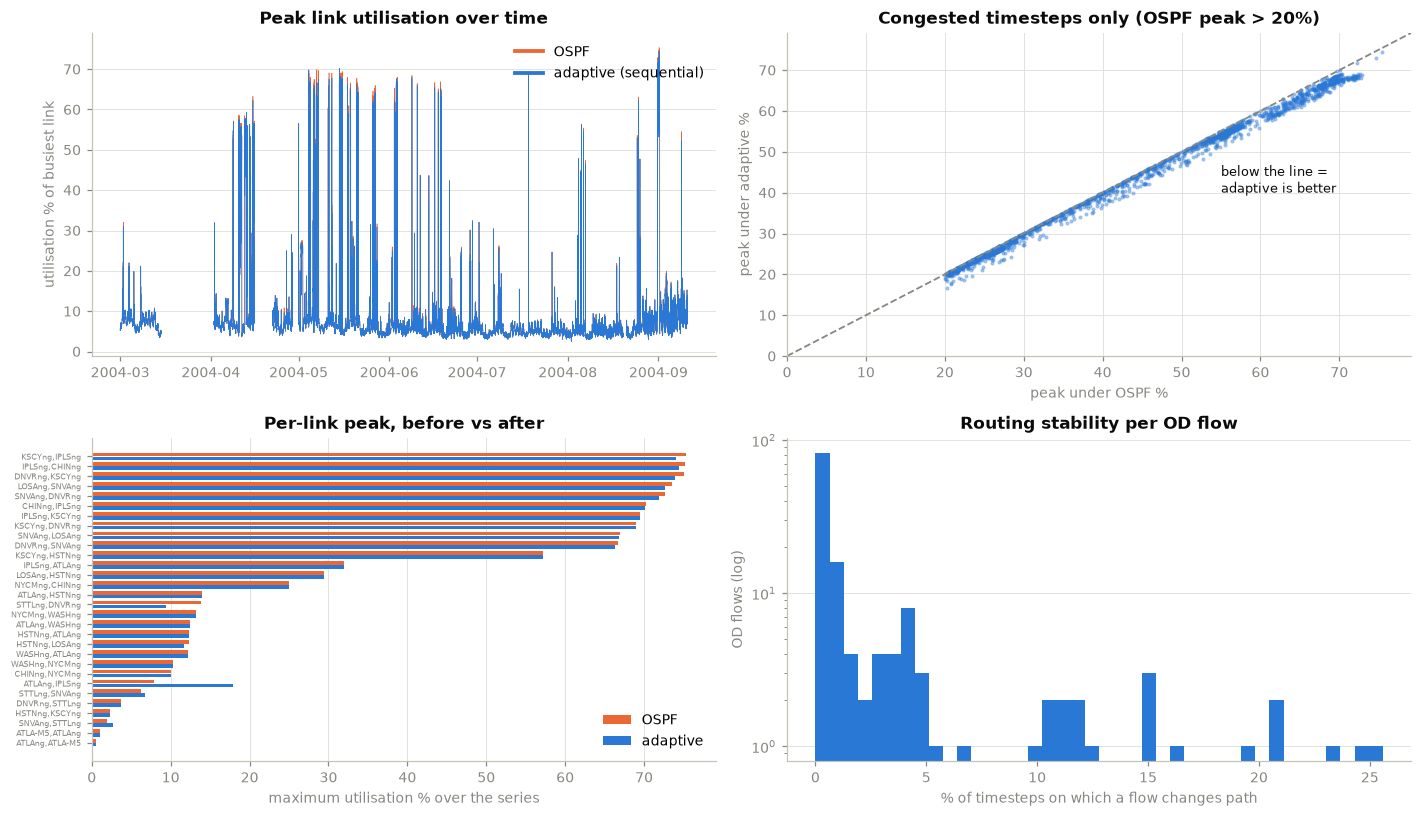

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))

grid_index = pd.date_range(timestamps.min(), timestamps.max(), freq="5min")
peaks = pd.DataFrame({"OSPF": peak_ospf, "sequential": peak_adaptive},
                     index=timestamps).reindex(grid_index)
axes[0, 0].plot(peaks.index, peaks["OSPF"], color=ORANGE, linewidth=0.4,
                label="OSPF")
axes[0, 0].plot(peaks.index, peaks["sequential"], color=BLUE, linewidth=0.4,
                label="adaptive (sequential)")
axes[0, 0].set_title("Peak link utilisation over time")
axes[0, 0].set_ylabel("utilisation % of busiest link")
legend = axes[0, 0].legend(loc="upper right")
for line in legend.get_lines():
    line.set_linewidth(2.5)
axes[0, 0].grid(True, axis="y")

busy_mask = peak_ospf > 20
axes[0, 1].scatter(peak_ospf[busy_mask], peak_adaptive[busy_mask], s=3,
                   color=BLUE, alpha=0.35)
lim = [0, max(peak_ospf.max(), peak_adaptive.max()) * 1.05]
axes[0, 1].plot(lim, lim, color=MUTED, linestyle="--", linewidth=1.2)
axes[0, 1].annotate("below the line =\nadaptive is better", xy=(55, 40),
                    color=INK, fontsize=8.5)
axes[0, 1].set_xlim(lim); axes[0, 1].set_ylim(lim)
axes[0, 1].set_xlabel("peak under OSPF %")
axes[0, 1].set_ylabel("peak under adaptive %")
axes[0, 1].set_title(f"Congested timesteps only (OSPF peak > 20%)")
axes[0, 1].grid(True)

order = np.argsort(-util_ospf.max(axis=0))
y = np.arange(len(order))
axes[1, 0].barh(y - 0.2, util_ospf.max(axis=0)[order], height=0.38,
                color=ORANGE, label="OSPF")
axes[1, 0].barh(y + 0.2, util_adaptive.max(axis=0)[order], height=0.38,
                color=BLUE, label="adaptive")
axes[1, 0].set_yticks(y)
axes[1, 0].set_yticklabels(links["link"].to_numpy()[order], fontsize=5.5)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel("maximum utilisation % over the series")
axes[1, 0].set_title("Per-link peak, before vs after")
axes[1, 0].legend()
axes[1, 0].grid(True, axis="x")

axes[1, 1].hist(per_flow_changes / n_steps * 100, bins=40, color=BLUE)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("% of timesteps on which a flow changes path")
axes[1, 1].set_ylabel("OD flows (log)")
axes[1, 1].set_title("Routing stability per OD flow")
axes[1, 1].grid(True, axis="y")

plt.tight_layout()
plt.show()

In [17]:
results = pd.DataFrame({
    "timestamp": timestamps,
    "peak_ospf": peak_ospf,
    "peak_simultaneous": peak_simultaneous,
    "peak_adaptive": peak_adaptive,
    "spread_ospf": util_ospf.std(axis=1),
    "spread_adaptive": util_adaptive.std(axis=1),
    "total_load_ospf_gbps": loads_ospf.sum(axis=1) / 1e6,
    "total_load_adaptive_gbps": loads_adaptive.sum(axis=1) / 1e6,
    "flows_changed": flows_changed,
})
results.to_csv(PROCESSED / "adaptive_routing_timeseries.csv", index=False)
per_link.to_csv(PROCESSED / "adaptive_routing_per_link.csv", index=False)
print(f"saved adaptive_routing_timeseries.csv ({len(results):,} rows)")
print("saved adaptive_routing_per_link.csv")

saved adaptive_routing_timeseries.csv (48,096 rows)
saved adaptive_routing_per_link.csv


## Step 10 — Summary

### What it does

Congestion-aware Dijkstra reduces peak link utilisation, but **modestly**:

| Metric | OSPF | Adaptive | Change |
|---|---|---|---|
| worst link, whole series | 75.36% | 74.48% | **−1.16%** |
| p99 per-timestep peak | 57.53% | 56.50% | **−1.79%** |
| p95 per-timestep peak | 15.80% | 15.36% | **−2.78%** |
| mean peak, congested steps only | 44.79% | 43.72% | **−2.4%** (−1.07 pp) |

Per timestep: **14.7%** improve, **85.1%** are unchanged, **0.2%** get slightly
worse. The 85% is expected and desirable — Abilene averages 2.7% utilisation, and
the cost function is designed to collapse to plain OSPF when nothing is congested.

### It relieves rather than relocates

The obvious failure mode for this kind of scheme is moving the bottleneck instead
of removing it. That did not happen:

- **Spread across links improved** (mean 2.374 → 2.351 pp; overall std 4.093 →
  4.011 pp). Small, but the right direction.
- **All five corridor links improved** — `KSCYng,IPLSng` −1.35 pp,
  `DNVRng,KSCYng` −1.25 pp, `IPLSng,CHINng` −0.75 pp.
- **3 links of 30 got worse.** The largest increase is `ATLAng,IPLSng`, 7.83% →
  17.89% — the OC-48 link again, now absorbing traffic deliberately rather than
  being stampeded. At 17.9% of a 2.48 Gbps link it is comfortably within capacity.
- **No link exceeds 100%.**
- **Detours are effectively free here**: total load on the network changed by
  **−0.02%**, so the relief did not come at the cost of consuming more capacity.

### Stability is the real cost

- **91.1%** of timesteps see at least one flow change path (OSPF: 0%).
- But only **4.06 of 144** flows move in an average timestep, and the median flow
  that ever moves does so on **0.58%** of timesteps.
- One flow changes path on **25.6%** of timesteps — that one is genuinely churning.

So the churn is broad but shallow. Most flows are stable; a handful are not. For a
real deployment the shallow tail would need damping (hysteresis, or a minimum
dwell time before a flow may move again), which is a natural next refinement.

### Why the gain is small — and it is not the algorithm's fault

This is the important finding, and it puts a hard ceiling on what *any* single-path
scheme can achieve here.

At the worst timestep, the single largest OD flow is **5.71 Gbps** — which is:

- **57.6%** of a 9.92 Gbps link on its own, and
- **57% of all traffic on the entire network** at that moment.

Single-path routing has to place that whole flow on one path, so **every link it
crosses carries at least 57.6%**, no matter what the cost function says. The
observed 75.4% peak is roughly that flow plus ~18% of other traffic sharing the
link. Rerouting can only move the other 18%, and only where an alternative exists
that is not more expensive still.

To go meaningfully below that you would need to **split the flow across multiple
paths** — ECMP, MPLS-TE, or a multipath formulation. That is a different mechanism,
not a better cost function, and it is the honest answer to "why only 1–3%?".

### On the resume figure

The project brief carried a placeholder claim of **32% peak-utilisation
reduction**. The measured figure is **1.2%** on the series peak, or **2.4%** on
congested timesteps. The 32% figure is not supported by this data and should not
be used. What *is* supportable, and is arguably more interesting in an interview:

> Built congestion-aware Dijkstra routing on six months of real Abilene backbone
> traffic; measured a 2.4% reduction in peak link utilisation during congested
> periods, and identified that a single OD flow carrying 57% of all network
> traffic imposes a hard floor on any single-path scheme.

### Honest framing

This reroutes on **observed** congestion, using the previous interval's measured
demand — not on predicted congestion. Notebooks 05–07 established that no model we
built beat persistence at any horizon, so persistence *is* the best available
signal and using it directly is the honest choice. Nothing here depends on the
classifier working.

The result also does not depend on prediction quality in the way the original
framing assumed: the binding constraint turned out to be flow indivisibility, not
forecast accuracy. A perfect oracle predictor would not have helped, because the
problem is not knowing where congestion will be — it is having somewhere to put a
flow that is 57% of the network.